In [317]:
import sys

sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt

#load the necessary odometry modules
from odometry.datasets.map_handler import MapHandler
from odometry.datasets.radnav_ds import radnavDS
from odometry.test_benches.temporal_pc_stacking_kalman_vel_filter_tb import temporalVelFilteringStackedTB
from odometry.localization.icp2D_localization import icp2DLocalization
from odometry.plotting.plotter_kalman import PlotterKalman
from odometry.plotting.movies import MovieGenerator
from odometry.point_cloud_processing.temporal_pc_stacker import temporalPcStacker


In [318]:
from dotenv import load_dotenv
import os

#loading enviroment variables
load_dotenv()
DATASET_PATH=os.getenv("DATASET_DIRECTORY")
MAP_DIRECTORY=os.getenv("MAP_DIRECTORY")

#setup the datasets
folder_name = "WILK_BASEMENT"
file_name = "wilk_basement_1"
dataset = radnavDS(
    dataset_path=os.path.join(DATASET_PATH,folder_name,file_name), #_spin_recall
    radar_folder="radar_0",
    lidar_folder="lidar",
    camera_folder="camera",
    imu_orientation_folder="imu_data",
    imu_full_folder="imu_data_full",
    vehicle_vel_folder="vehicle_vel"
)

map_handler = MapHandler(
    maps_folder=MAP_DIRECTORY,
    map_file="wilk_basement.yaml"
)

found 2372 radar samples
found 2372 lidar samples
found 2372 camera samples
found 2372 imu (orientation only) samples
found 2372imu (full data) samples
found 2372 vehicle velocity samples
loaded map from /data/radnav/maps/wilk_basement.yaml
loaded map free space from /data/radnav/maps/wilk_basement.yaml


In [319]:
#initialize the localizers
radar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.5,#originally 0.1
    icp_best_points_percentile=80, #originally 65
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=7, #originally 5
    icp_max_iterations=20,
    self_detection_radius_m=0 #originally 1.5
)

lidar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.6, #originally 0.6
    icp_best_points_percentile=50,
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=10,
    icp_max_iterations=20,
    self_detection_radius_m=0.25
)

In [320]:
#initialize the point cloud stacker
pc_stacker = temporalPcStacker(
    num_frames_static_history = 4,
    num_frames_dynamic_history = 0,
    refresh_distance_m = 3,
    refresh_rot_deg = 90,
    refresh_time_s = 10,
    grid_resolution_m = 5e-2,
    grid_max_distance_m = 20,
    multi_path_clustering_eps = 0.5, #was 0.5
    multi_path_clustering_min_samples = 15, #was 15
    multi_path_num_frames_history=4,
    vel_filtering_enabled = True,
    vel_filtering_v_thresh = 0.05,
    vel_filtering_min_static_rejection_radius = 0.25, #was 0.5
    vel_filtering_dynamic_cluster_eps = 0.5, #was 1.0
    vel_filtering_dynamic_cluster_min_samples = 15,
    min_detection_radius_m=1.5,
    max_detection_range_m=20
)

loaded map with 16346 points
loaded map with 16346 points
gt icp estimated heading:4.012580016084061 deg, pose:[-0.08044763  0.03828567]
radar icp estimated heading:-2.4742694725091328 deg, pose:[-0.08651019  0.29806553]


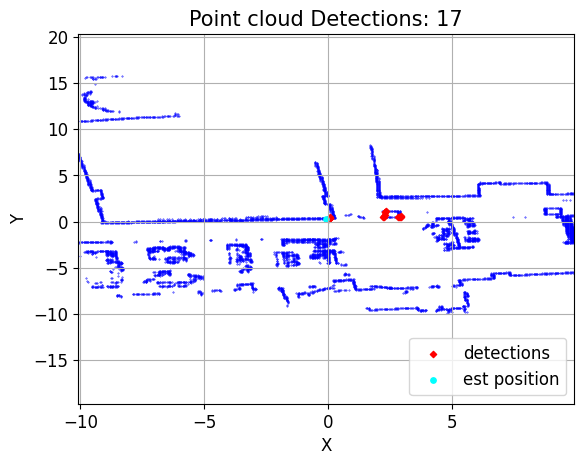

In [321]:
test_bench = temporalVelFilteringStackedTB(
    localizer=radar_odometry,
    gt_localizer=lidar_odometry,
    map_handler=map_handler,
    dataset=dataset,
    pc_stacker=pc_stacker
)

start_heading = np.deg2rad(0)
start_pose = np.array([0.03,0.11])

#initialize the localization
new_heading_rad,new_pose_m = test_bench.init_localization(
    est_start_heading_rad=start_heading,
    est_start_pose_m=start_pose,
    show=True
)

#initialize the filter
test_bench.init_filter(
    est_start_heading_rad=start_heading,
    est_start_position_m=start_pose,
    start_time_s=test_bench.get_dataset_start_time(idx=0)
)

#initialize the point cloud stacker
test_bench.init_pc_stacker(
    start_time_s=test_bench.get_dataset_start_time(idx=0)
)

found temp dir: /home/david/Downloads/radnav_temp_dir
clearing temp directory /home/david/Downloads/radnav_temp_dir


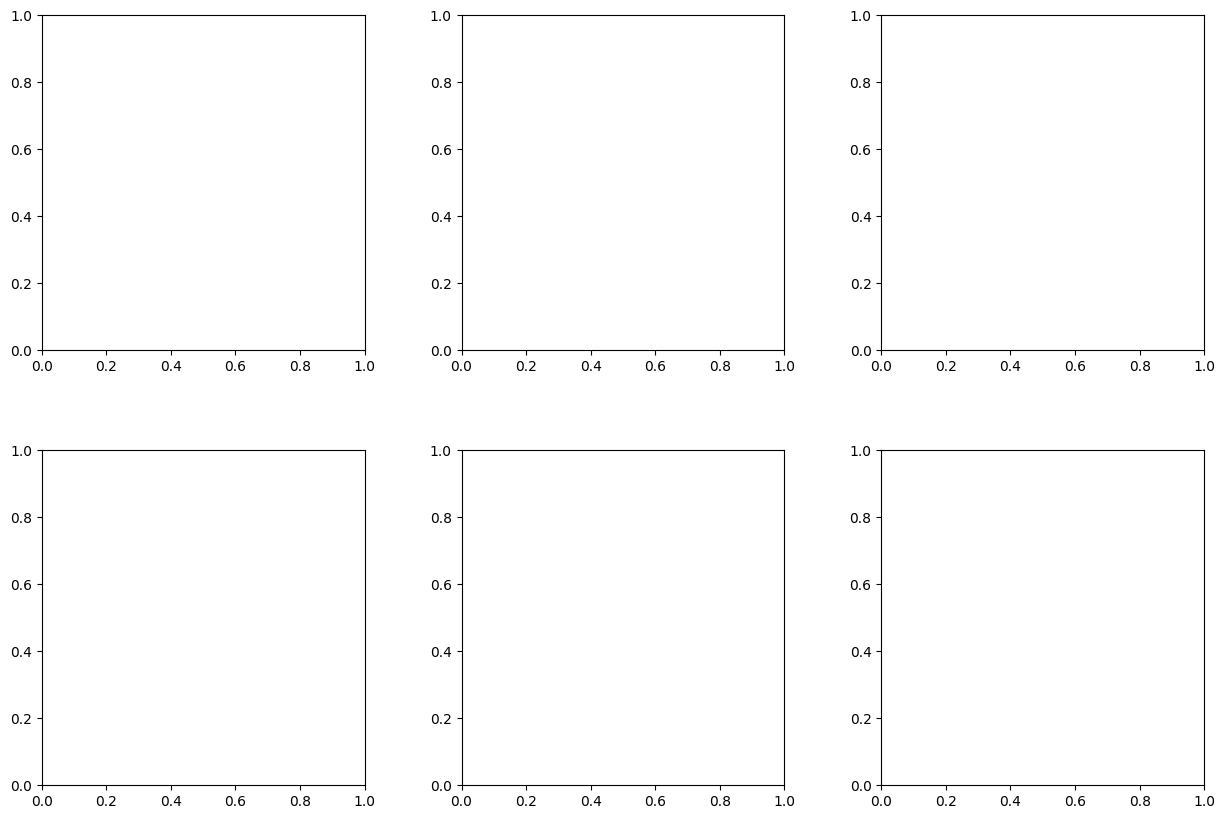

In [322]:
#loading directory from .env file
MOVIE_TEMP_DIRECTORY = os.getenv("MOVIE_TEMP_DIRECTORY")

#initialize the movie maker
movie_generator = MovieGenerator(
    temp_dir_path=MOVIE_TEMP_DIRECTORY
)
movie_generator.initialize_figure(
    nrows=2,
    ncols=3,
    figsize=(15,10)
)

In [323]:
end_idx = dataset.num_frames
save_name = file_name + "radar_0"
test_bench.run(
    max_frame=end_idx,
    gt_enabled=True,
    movie_generator=movie_generator) #=movie_generator)

100%|██████████| 2372/2372 [17:12<00:00,  2.30it/s]


In [324]:
movie_generator.save_movie(video_file_name="{}.mp4".format(save_name),fps=20)

100%|██████████| 2372/2372 [02:22<00:00, 16.68it/s]


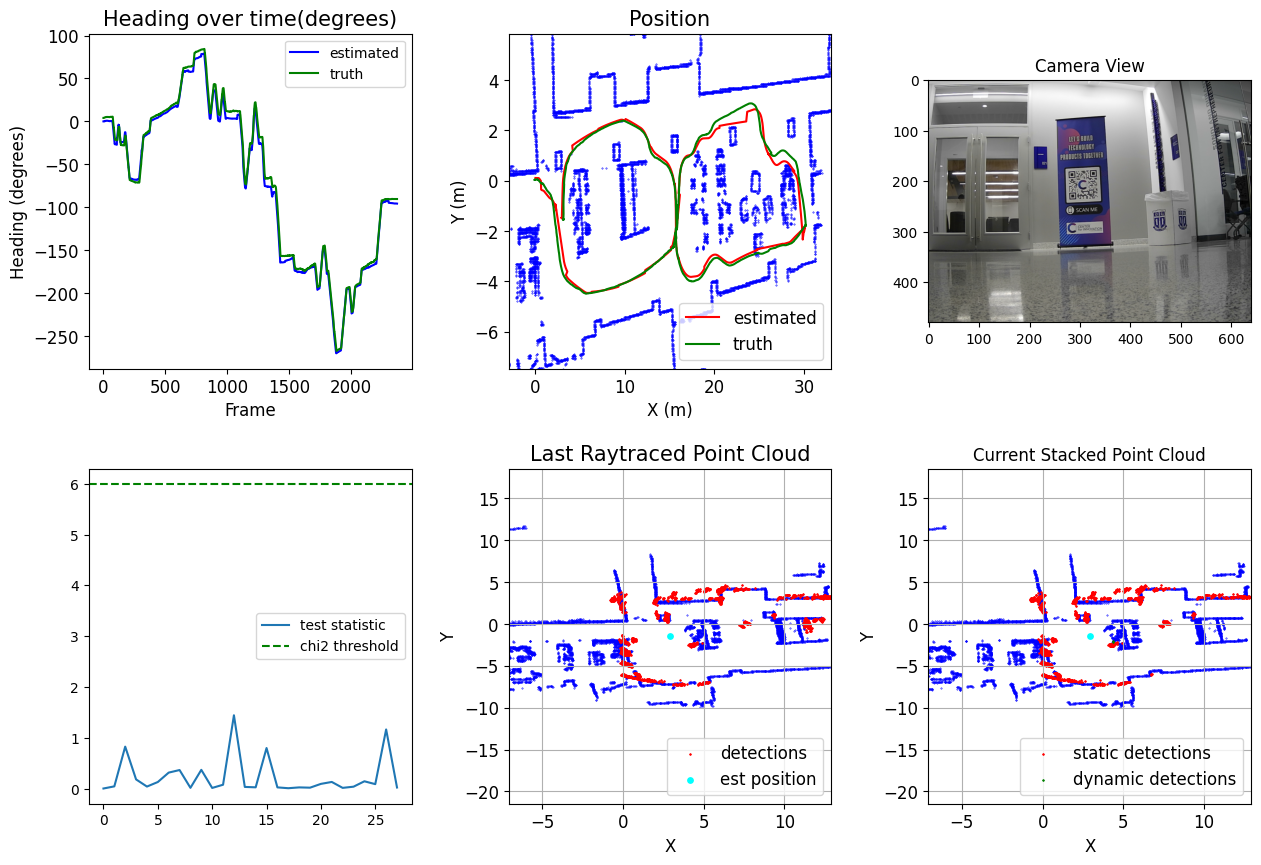

In [325]:
test_bench.plot_compilation(
    idx=end_idx-1,
    show=True
)

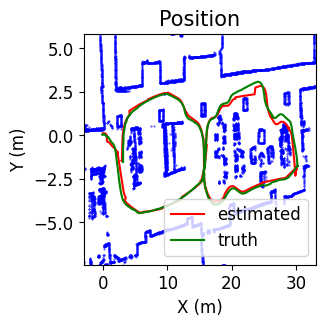

In [326]:
test_bench.plotter_localization.plot_position_history_m(
    test_bench.history_position_m,
    test_bench.history_position_m_gt,
    idx=end_idx-1,
    show=True
)

In [327]:
print(test_bench.filter.x[0:3])
print(test_bench.gt_localizer.current_pose_m)
print(test_bench.point_cloud_stacker.integrator.x[0:3])
print(test_bench.point_cloud_stacker.initial_pose_m)
print(test_bench.point_cloud_stacker.current_pose_m)
print(np.linalg.norm(test_bench.gt_localizer.current_pose_m - test_bench.filter.x[0:2]))

[ 2.9221218 -1.4720822 -1.6709302]
[ 3.14628508 -1.54125399]
[ 7.46799588  7.37924205 -2.47557881]
[7.46799588 7.37924205]
[7.46799588 7.37924205]
0.2345930815554791


In [328]:
#compute total distance traveled
dist = 0
for i in range(len(test_bench.history_position_m)-1):
    dist += np.linalg.norm(
        test_bench.history_position_m_gt[i+1] -\
        test_bench.history_position_m_gt[i]
    )

print(dist)

74.11338287173736


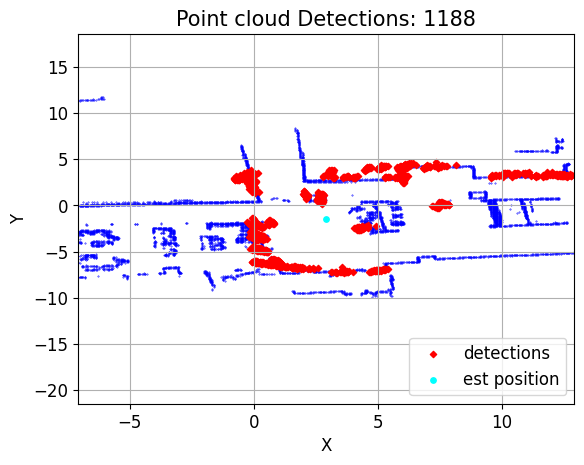

In [329]:
#debugging temporal pc stack
pc = test_bench.point_cloud_stacker.get_current_stacked_pc_static()
pc = test_bench.point_cloud_stacker.multi_path.remove_multipath(pc)
test_bench.plotter_localization.plot_detections_on_map(
    current_points=pc,
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2]
)

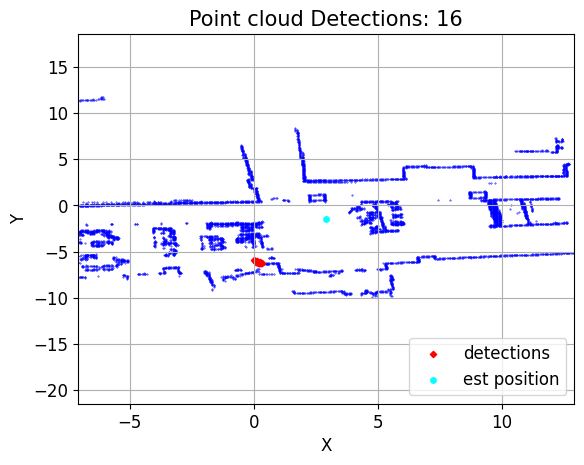

In [330]:
#debugging temporal pc stack
pc_grid = test_bench.point_cloud_stacker.pc_grid_static[0:1]
pc = test_bench.point_cloud_stacker._get_points_from_pc_grids(pc_grid)
pc = test_bench.point_cloud_stacker._change_pc_reference_frame(
    initial_heading_rad=test_bench.point_cloud_stacker.initial_heading_rad,
    initial_pose_m=test_bench.point_cloud_stacker.initial_pose_m,
    current_heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    current_pose_m=test_bench.point_cloud_stacker.current_pose_m,
    current_points=pc
)
pc = test_bench.point_cloud_stacker.multi_path.remove_multipath(pc)


test_bench.plotter_localization.plot_detections_on_map(
    current_points=pc,
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2]
)

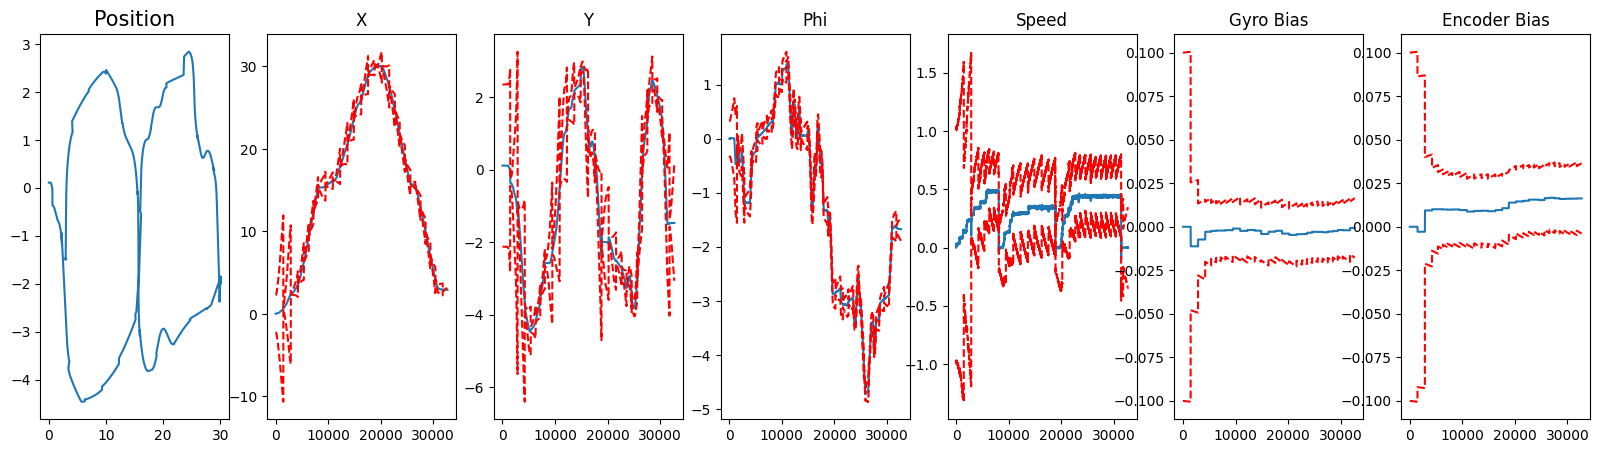

In [331]:
#plot kalman state history
kalman_plotter = PlotterKalman()

kalman_plotter.plot_kalman_result_history(
    x_history=np.array(test_bench.history_filter_est),
    p_history=np.array(test_bench.history_filter_p),
    idx=-1
)

100%|██████████| 27/27 [00:00<00:00, 339.63it/s]


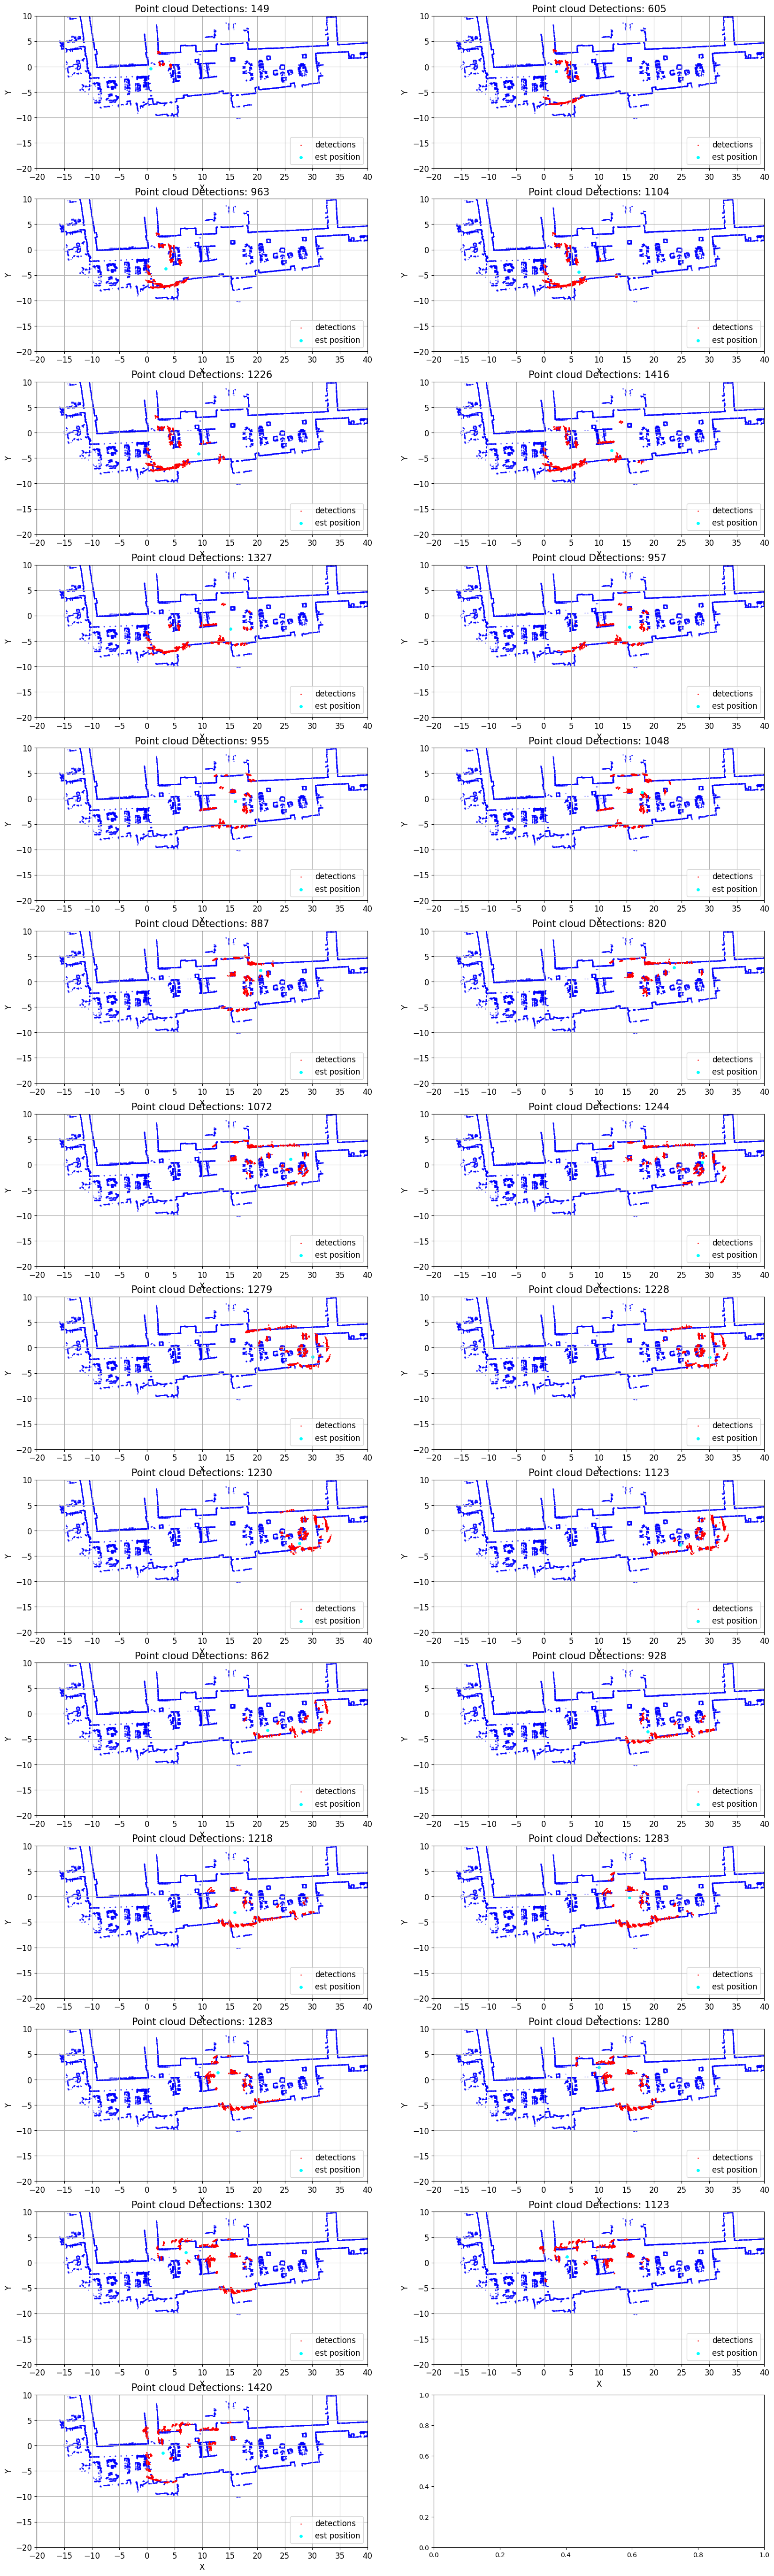

In [332]:
from tqdm import tqdm

r = int(len(test_bench.history_pc_stacker_point_clouds)/2) + 1
c = 2

fig, axs = plt.subplots(r, c, figsize = (20, 5 * r))

rc = 0
cc = 0
test_bench.plotter_localization.marker_size=0.5
for idx in tqdm(range(len(test_bench.history_pc_stacker_point_clouds))):
    test_bench.plotter_localization.plot_detections_on_map(
        current_points=test_bench.history_pc_stacker_point_clouds[idx],
        heading_rad=test_bench.history_pc_stacker_heading_rad[idx],
        pose_m=test_bench.history_pc_stacker_position_m[idx],
        ax=axs[cc,rc],
        show=False
    )
    axs[cc,rc].set_ylim(-20,10)
    axs[cc,rc].set_xlim(-20, 40)
    rc += 1
    if(rc == c) :
        rc = 0
        cc += 1
        
fig.savefig("Images/images/{}.png".format(save_name))
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

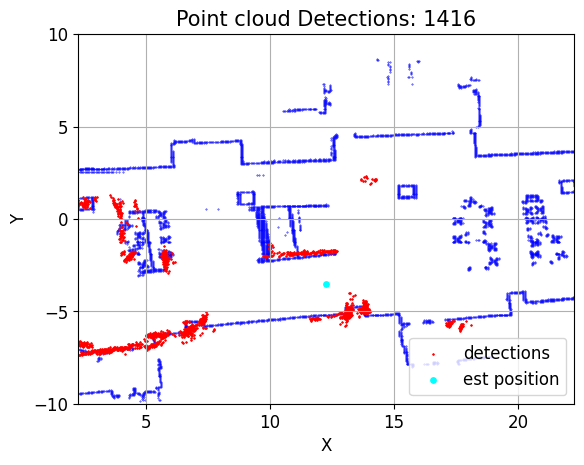

In [333]:
#plotting the saved ray traced point clouds
# plot the lidar point cloud
idx = 5
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=test_bench.history_pc_stacker_point_clouds[idx],
    heading_rad=test_bench.history_pc_stacker_heading_rad[idx],
    pose_m=test_bench.history_pc_stacker_position_m[idx],
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show

In [334]:
test_bench.analyze()

,Metric,Euclidian,x,y,phi
0,Mean,0.253892,-0.028330,0.050424,-0.070945
1,Variance,0.027261,0.040372,0.048006,0.004468
2,Median,0.206431,-0.005631,-0.038948,-0.066886
3,0.9th percentile,0.527923,0.326737,0.361175,0.158348


## Debugging (testing ray tracing)

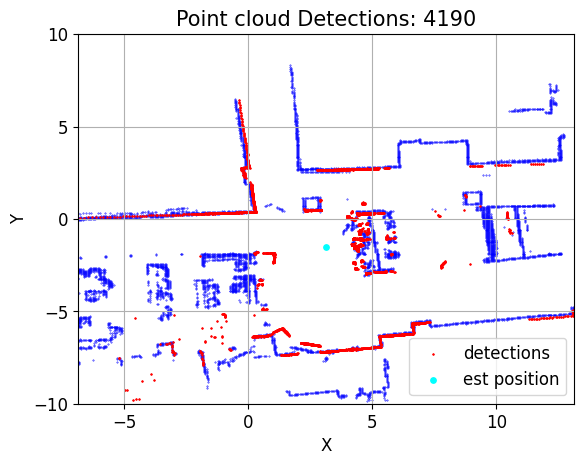

In [335]:
# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.plot_lidar_points_on_map(
    idx=end_idx-1,
    heading_rad=test_bench.gt_localizer.current_heading_rad,
    pose_m=test_bench.gt_localizer.current_pose_m,
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show()

0.0
6.5831005573272705


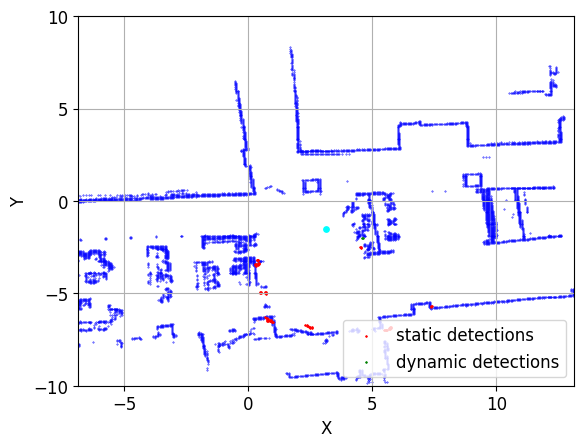

In [336]:
#recenter the point cloud grids
pc_grids_static = test_bench.point_cloud_stacker.recenter_pc_grids(
    grids=test_bench.point_cloud_stacker.pc_grid_static,
    initial_heading_rad=test_bench.point_cloud_stacker.initial_heading_rad,
    initial_pose_m=test_bench.point_cloud_stacker.initial_pose_m,
    current_heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    current_pose_m=test_bench.point_cloud_stacker.current_pose_m
)

pc_grid_dynamic = test_bench.point_cloud_stacker.recenter_pc_grids(
    grids=test_bench.point_cloud_stacker.pc_grid_dynamic,
    initial_heading_rad=test_bench.point_cloud_stacker.initial_heading_rad,
    initial_pose_m=test_bench.point_cloud_stacker.initial_pose_m,
    current_heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    current_pose_m=test_bench.point_cloud_stacker.current_pose_m
)


current_points = test_bench.point_cloud_stacker._get_points_from_pc_grids(pc_grids_static[0:1])
dynamic_points = test_bench.point_cloud_stacker._get_points_from_pc_grids(pc_grid_dynamic)

print(test_bench.point_cloud_stacker.get_rel_distance_m())
print(test_bench.point_cloud_stacker.get_elapsed_time())

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_dynamic_and_static_detections_on_map(
    static_points=current_points,
    dynamic_points = dynamic_points,
    heading_rad = test_bench.gt_localizer.current_heading_rad,
    pose_m= test_bench.gt_localizer.current_pose_m,
    ax = ax,
    show = False
)
ax.set_ylim(-10,10)
plt.show()

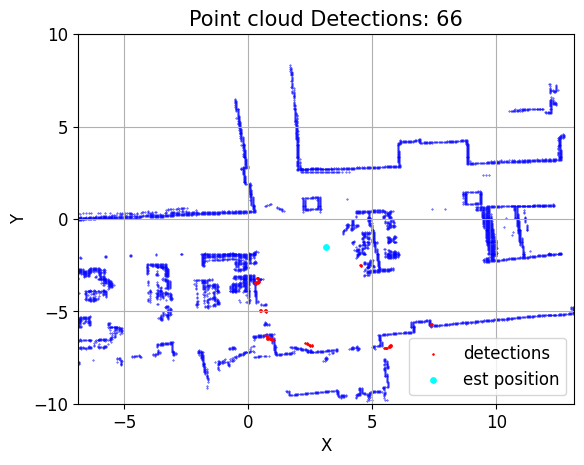

In [337]:
#remove velocity detections
current_points = \
    test_bench.point_cloud_stacker.vel_filtering.remove_dynamic_clusters_from_static_detections_knn(
        current_points,
        dynamic_points
    )

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_detections_on_map(
    current_points=current_points,
    heading_rad = test_bench.gt_localizer.current_heading_rad,
    pose_m= test_bench.gt_localizer.current_pose_m,
    ax = ax,
    show = False
)

ax.set_ylim(-10,10)
plt.show()

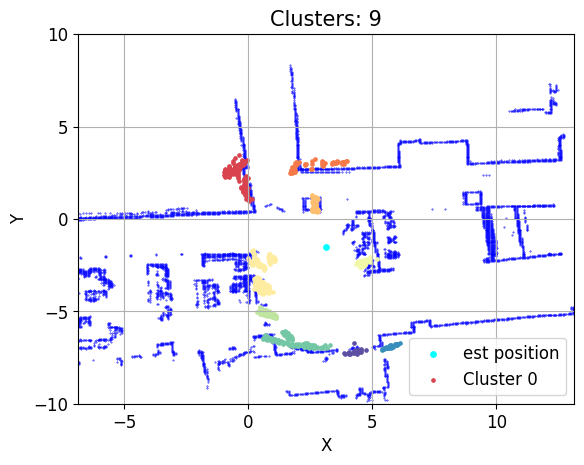

In [338]:
#perform current multi-path
multipath_num_frames_history = 2

#update the static point grid
pc_grids_static[0] = test_bench.point_cloud_stacker._get_pc_grid_from_points(current_points)
current_points = test_bench.point_cloud_stacker._get_points_from_pc_grids(
    pc_grids_static[0:multipath_num_frames_history+1])

labels = test_bench.point_cloud_stacker.multi_path._cluster_points(current_points)

fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_detection_clusters_on_map(
    current_points=current_points,
    labels=labels,
    heading_rad = test_bench.gt_localizer.current_heading_rad,
    pose_m= test_bench.gt_localizer.current_pose_m,
    ax = ax,
    show = False
)


ax.set_ylim(-10,10)
plt.show()

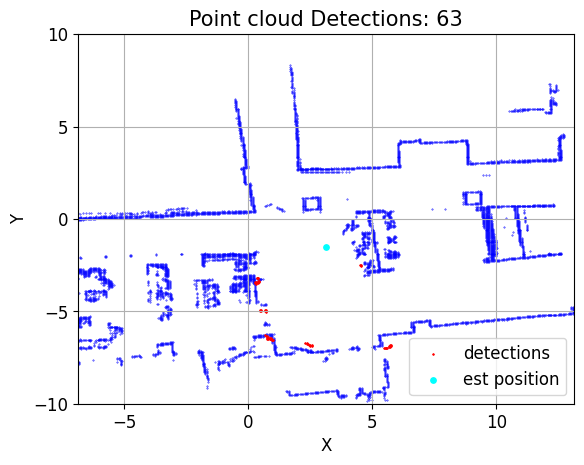

In [339]:
#remove velocity detections
current_points = test_bench.point_cloud_stacker.multi_path.remove_multipath(
    pc_cartesian=current_points
)

grid = test_bench.point_cloud_stacker._get_pc_grid_from_points(current_points)
pc_grids_static[0] = np.logical_and(grid,pc_grids_static[0])

current_points = test_bench.point_cloud_stacker._get_points_from_pc_grid(pc_grids_static[0])

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_detections_on_map(
    current_points=current_points,
    heading_rad = test_bench.gt_localizer.current_heading_rad,
    pose_m= test_bench.gt_localizer.current_pose_m,
    ax = ax,
    show = False
)

ax.set_ylim(-10,10)
plt.show()

In [340]:
from tqdm import tqdm 

for i in tqdm(range(1000)):
    valid_stacked_pc_cart = test_bench.point_cloud_stacker.multi_path.remove_multipath(current_points)

100%|██████████| 1000/1000 [00:00<00:00, 1247.72it/s]


### Debugging ICP

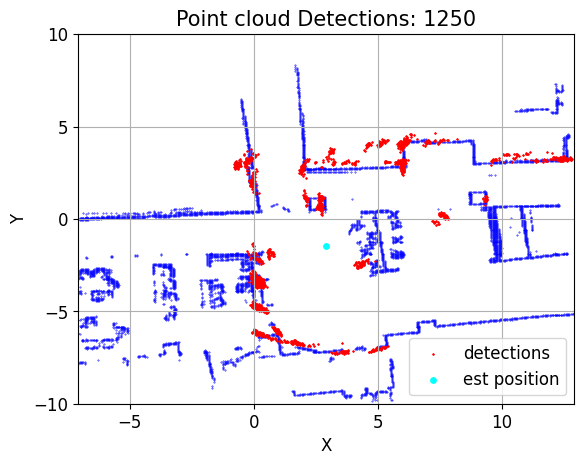

In [341]:
#get the point cloud (from the previous step)
current_points = test_bench.point_cloud_stacker._get_points_from_pc_grids(
    pc_grids_static
)
# plot the point cloud before icp
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_detections_on_map(
    current_points=current_points,
    heading_rad = test_bench.filter.x[2],
    pose_m= test_bench.filter.x[0:2],
    ax = ax,
    show = False
)

ax.set_ylim(-10,10)
plt.show()

loaded map with 16346 points


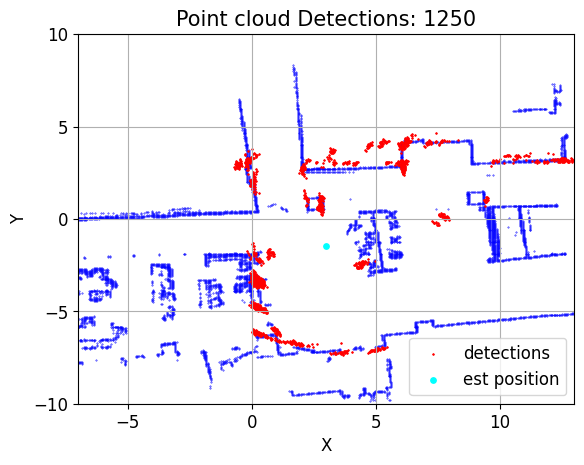

In [342]:
#testing icp
icp_tb = icp2DLocalization(
    icp_matching_distance_threshold=0.1,#originally 0.1
    icp_best_points_percentile=95, #originally 65
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=7, #originally 5
    icp_max_iterations=100,
    self_detection_radius_m=0 #originally 1.5
)

icp_tb.load_map_point_cloud(map_handler.map_points)

#reset the odometry
icp_tb.reset_odometry(
    pose=test_bench.filter.x[0:2],
    heading_rad=test_bench.filter.x[2]
)

#update the odometry
new_heading_rad,new_pose_m = icp_tb.update_odometry(
    points=current_points,
    estimated_heading_rad=test_bench.filter.x[2],
    estimated_pose_m=test_bench.filter.x[0:2]
)

# plot the after the icp update
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_detections_on_map(
    current_points=current_points,
    heading_rad = new_heading_rad,
    pose_m= new_pose_m,
    ax = ax,
    show = False
)

ax.set_ylim(-10,10)
plt.show()